    Instructions:
    1. Run task_2.py to generate the tensor database if not already generated.
    2. Press Run All (or restart kernel and run all cells).
    3. You will be prompted to provide an image ID and a k value.


    Task 3: Implement a program which, given an image ID and a value “k”, returns and 
    visualizes the most similar k images based on each of the visual model -you will
    select the appropriate distance/similarity measure for each feature model.
    For each match, also list the corresponding distance/similarity score.

In [169]:
IMG_ID = int(input("Provide an Image ID in the Caltech101 dataset in range [0, 8676]."))

K = int(input("Enter K, the number of similar images K to find for each feature model."))

In [170]:
# Initialize dataset, downloads into <git_root>/Code/caltech101 if not present. Untracked by git.

import os
from torchvision.datasets import Caltech101

dataset = Caltech101(root=os.path.abspath(""), download=True)

Files already downloaded and verified


Input image:
Image ID:  2500


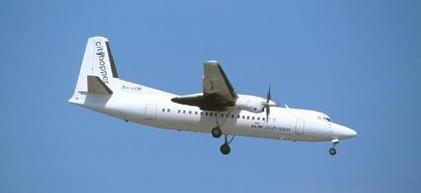

Category: airplanes


In [171]:
# Find the k most similar images for a given Image ID for each feature model.

image, category = dataset[IMG_ID][0], dataset.categories[dataset[IMG_ID][1]]

if image.mode != 'RGB':
    print("WARNING: The provided image does not have RGB channels, the image will be converted to RGB.")
    image = image.convert('RGB')

print("Input image:\nImage ID: ", IMG_ID)
display(image)
print("Category:", category)

In [172]:
# Resize to 300x100 and partition to grid.

image300x100 = image.resize((300, 100))

from utils.utilities import partition_to_grid

grid = partition_to_grid(image300x100, num_rows=10, num_cols=10, hor_pixels=30, ver_pixels=10)

Similar images by Color Moments using distance: Manhattan (cityblock)
1. 	Image ID:  2500 		Distance:  0.0


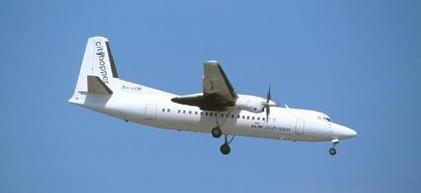

2. 	Image ID:  2301 		Distance:  10972.34


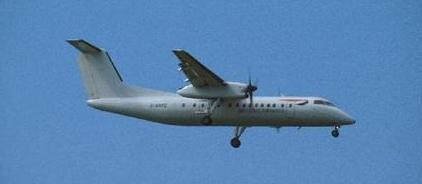

3. 	Image ID:  2519 		Distance:  11094.308


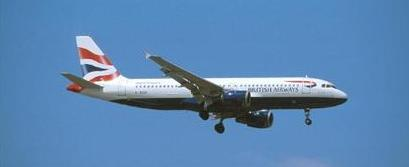

4. 	Image ID:  2524 		Distance:  11336.744


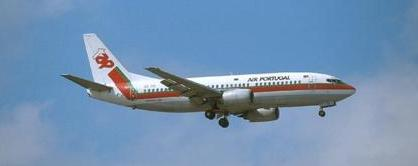

5. 	Image ID:  2308 		Distance:  12073.262


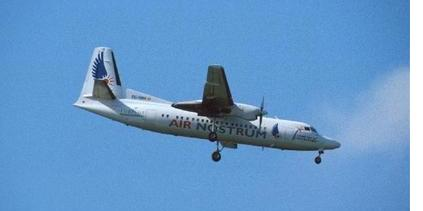

6. 	Image ID:  2196 		Distance:  12535.328


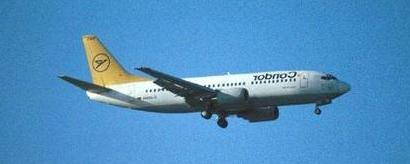

7. 	Image ID:  2245 		Distance:  12603.198


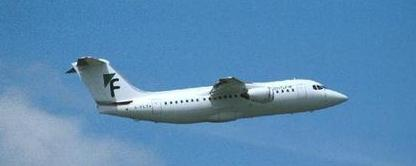

8. 	Image ID:  2410 		Distance:  13100.132


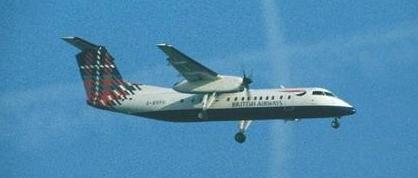

9. 	Image ID:  5007 		Distance:  13128.953


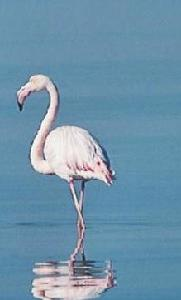

10. 	Image ID:  2670 		Distance:  13422.051


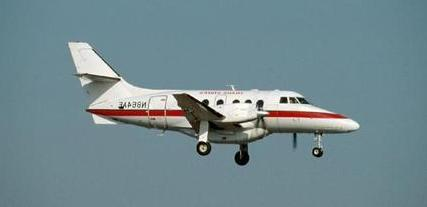

In [173]:
# Color moments (CM10x10).

# Find K most similar images by color moments.

from feature_extractors.color_moments import get_color_vector

color_vector = get_color_vector(grid)

# Load color tensor database into memory.

from utils.utilities import tensor_loader

color_tensor_dict = tensor_loader('color_tensors.pt', os.path.abspath(""))

from utils.utilities import top_k_ranker

# Manhattan distance (City-block distance): This distance can be imagined as the length needed 
# to move between two points in a grid where you can only move up, down, left or right. This 
# measure is sensitive to differences along each dimension of the feature vectors, capturing 
# the total absolute difference between corresponding moments, which makes it great for 
# assessing differences in color distribution in terms of absolute deviations. Since it 
# does not square the differences like Euclidean distance, it is less susceptible outliers 
# when many dimensions differ.

# We use Earth Mover's Distance (Wasserstein distance) as color moments can be thought
# of as probability distributions over color space. EMD is capable of comparing distributions
# with different shapes and scales, color moments consider the spatial arrangement of colors, 
# not just the frequency of colors. EMD takes this spatial information into account by 
# considering how color probability mass is transported from one distribution to another. 

from scipy.spatial.distance import cityblock

print("Similar images by Color Moments using distance: Manhattan (cityblock)")

top_k_by_color = top_k_ranker(K, color_vector, color_tensor_dict, cityblock)


for i in range(len(top_k_by_color)):

    id = top_k_by_color[i][1]
    distance = top_k_by_color[i][0]

    print(str(i + 1) + ".", "\tImage ID: ", id, "\t\tDistance: ", distance)
    display(dataset[id][0])

In [174]:
# Convert to grayscale and partition to grid.

from torchvision.transforms import Grayscale

gs_image = Grayscale()(image300x100)

gs_grid = partition_to_grid(gs_image, num_rows=10, num_cols=10, hor_pixels=30, ver_pixels=10)

Similar images by Histogram of Oriented Gradients (HOG) using distance: Correlation
1. 	Image ID:  2500 		Distance:  0.0


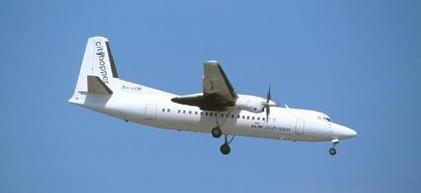

2. 	Image ID:  2121 		Distance:  0.0661546313127187


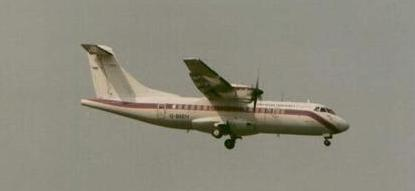

3. 	Image ID:  2308 		Distance:  0.06905893472781599


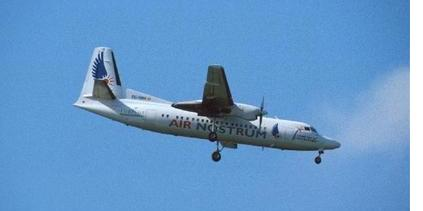

4. 	Image ID:  2094 		Distance:  0.07435084787559465


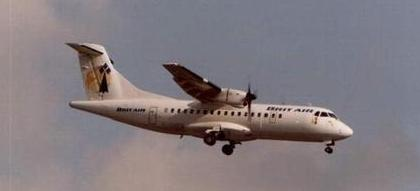

5. 	Image ID:  2673 		Distance:  0.07991670203757606


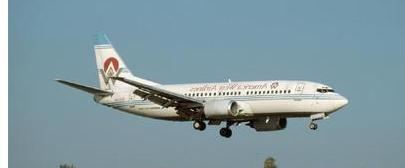

6. 	Image ID:  5038 		Distance:  0.08053593607760079


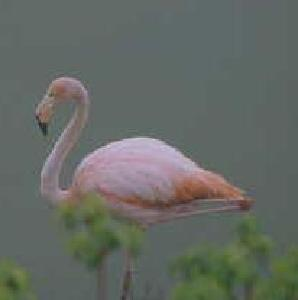

7. 	Image ID:  2167 		Distance:  0.08069762336058162


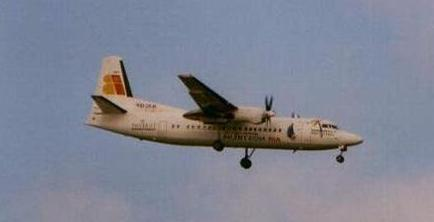

8. 	Image ID:  2609 		Distance:  0.08195859934637628


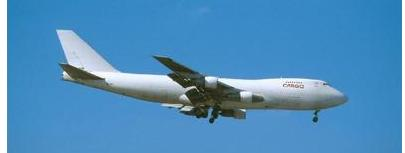

9. 	Image ID:  2301 		Distance:  0.08204215381630864


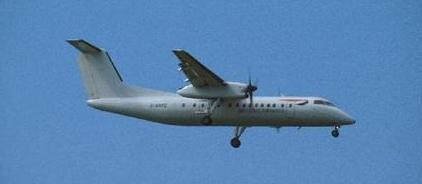

10. 	Image ID:  2191 		Distance:  0.08445441642668183


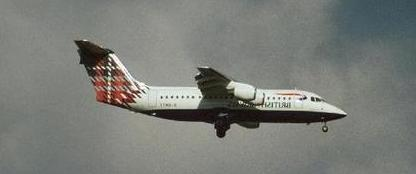

In [175]:
# Histograms of oriented gradients (HOG).

# Find K most similar images by HOG.

from feature_extractors.HOG import get_hog_vector

hog_vector = get_hog_vector(gs_grid)

# Load hog tensor database into memory.

hog_tensor_dict = tensor_loader('hog_tensors.pt', os.path.abspath(""))

# Correlation similarity: This measures the linear relationship between HOG feature vectors,
# and performs well with features that have a strong linear correlation or dependency in 
# their gradient orientation distributions, taking into account directionality.

from scipy.spatial.distance import correlation

print("Similar images by Histogram of Oriented Gradients (HOG) using distance: Correlation")

top_k_by_hog = top_k_ranker(K, hog_vector, hog_tensor_dict, correlation)


for i in range(len(top_k_by_hog)):

    id = top_k_by_hog[i][1]
    distance = top_k_by_hog[i][0]

    print(str(i + 1) + ".", "\tImage ID: ", id, "\t\tDistance: ", distance)
    display(dataset[id][0])

In [176]:
# Resize original image to 224x224 and convert to float tensor.

from torchvision.transforms import transforms

image224x224 = image.resize((224, 224))

img_tensor = transforms.Compose([transforms.ToTensor()])(image224x224)

In [177]:
# ResNet pre-processing.

# Find K most similar images by each of the 3 layers chosen from ResNet-50.

from feature_extractors.resnet_50 import get_resnet50_feature_vectors

avgpool_vector, layer3_vector, fc1000_vector = get_resnet50_feature_vectors(img_tensor)

# Load each tensor database into memory

avgpool_tensor_dict = tensor_loader('avgpool_tensors.pt', os.path.abspath(""))
layer3_tensor_dict = tensor_loader('layer3_tensors.pt', os.path.abspath(""))
fc1000_tensor_dict = tensor_loader('fc1000_tensors.pt', os.path.abspath(""))

Similar images by ResNet-AvgPool-1024 using distance: Cosine
1. 	Image ID:  2500 		Distance:  0


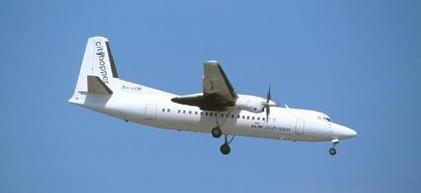

2. 	Image ID:  2308 		Distance:  0.06326800584793091


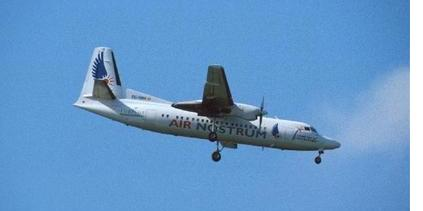

3. 	Image ID:  2167 		Distance:  0.08668988943099976


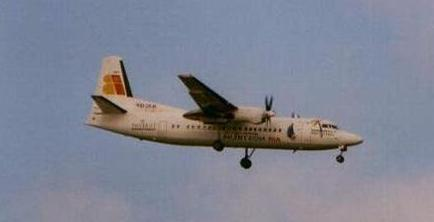

4. 	Image ID:  2527 		Distance:  0.09355634450912476


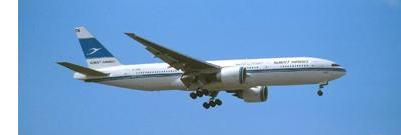

5. 	Image ID:  2254 		Distance:  0.10535889863967896


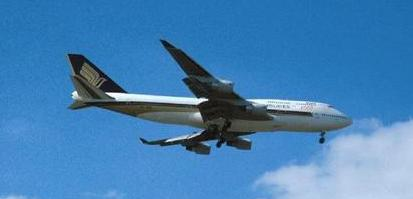

6. 	Image ID:  2301 		Distance:  0.11197084188461304


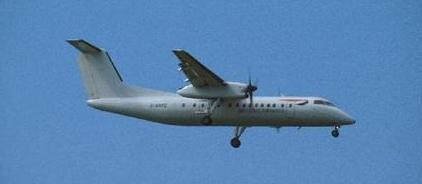

7. 	Image ID:  2398 		Distance:  0.11582589149475098


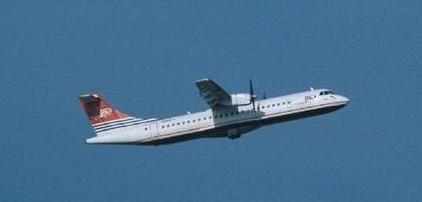

8. 	Image ID:  2226 		Distance:  0.11904072761535645


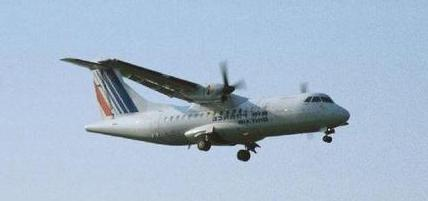

9. 	Image ID:  2412 		Distance:  0.1205405592918396


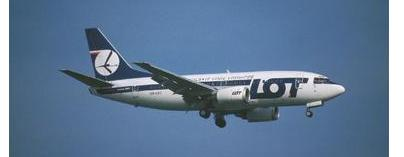

10. 	Image ID:  2670 		Distance:  0.12307322025299072


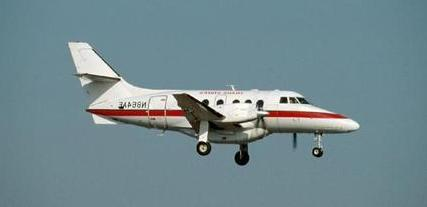

In [178]:
# ResNet-AvgPool-1024.

# Find K most similar images by ResNet-AvgPool-1024.

# Cosine similarity: We use Cosine since the output of the ResNet layer is 
# normalized, reducing the importance of magnitude. It is good at discerning 
# semantic or structural similarity rather than their absolute feature values. 
# It also works well with sparse feature spaces such as those found in CNNs.

from scipy.spatial.distance import cosine

print("Similar images by ResNet-AvgPool-1024 using distance: Cosine")

top_k_by_avgpool = top_k_ranker(K, avgpool_vector, avgpool_tensor_dict, cosine)


for i in range(len(top_k_by_avgpool)):

    id = top_k_by_avgpool[i][1]
    distance = top_k_by_avgpool[i][0]

    print(str(i + 1) + ".", "\tImage ID: ", id, "\t\tDistance: ", distance)
    display(dataset[id][0])

Similar images by ResNet-Layer3-1024 using distance: Cosine
1. 	Image ID:  2500 		Distance:  0


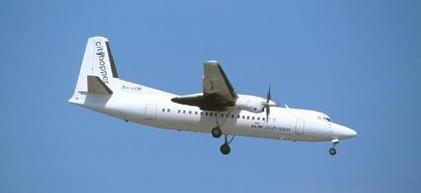

2. 	Image ID:  2519 		Distance:  0.012333095073699951


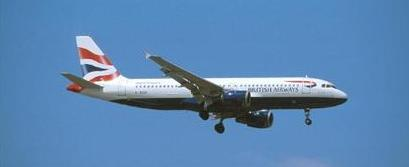

3. 	Image ID:  2413 		Distance:  0.013264119625091553


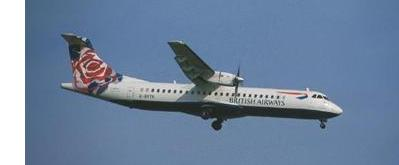

4. 	Image ID:  2217 		Distance:  0.015680968761444092


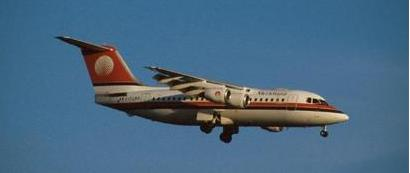

5. 	Image ID:  2624 		Distance:  0.016152143478393555


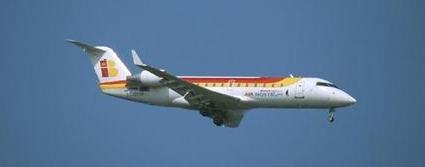

6. 	Image ID:  2569 		Distance:  0.016269266605377197


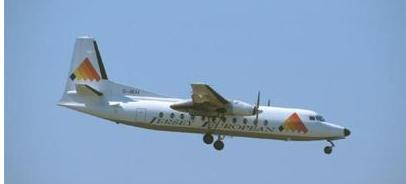

7. 	Image ID:  2527 		Distance:  0.016563475131988525


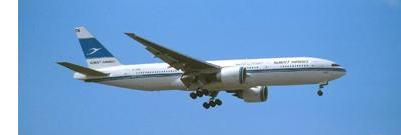

8. 	Image ID:  2625 		Distance:  0.01666736602783203


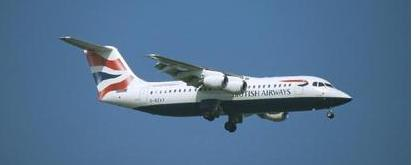

9. 	Image ID:  2509 		Distance:  0.01810145378112793


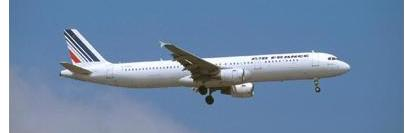

10. 	Image ID:  2411 		Distance:  0.01848888397216797


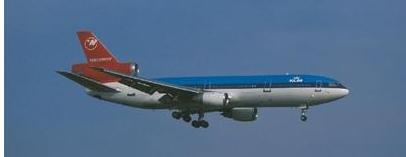

In [179]:
# ResNet-Layer3-1024.

# Find K most similar images by ResNet-Layer3-1024.

# Cosine similarity: We use Cosine since the output of the ResNet layer is 
# normalized, reducing the importance of magnitude. It is good at discerning 
# semantic or structural similarity rather than their absolute feature values. 
# It also works well with sparse feature spaces such as those found in CNNs.

print("Similar images by ResNet-Layer3-1024 using distance: Cosine")

top_k_by_layer3 = top_k_ranker(K, layer3_vector, layer3_tensor_dict, cosine)


for i in range(len(top_k_by_layer3)):

    id = top_k_by_layer3[i][1]
    distance = top_k_by_layer3[i][0]

    print(str(i + 1) + ".", "\tImage ID: ", id, "\t\tDistance: ", distance)
    display(dataset[id][0])

Similar images by ResNet-FC-1000 using distance: Cosine
1. 	Image ID:  2500 		Distance:  0


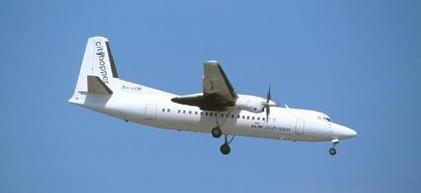

2. 	Image ID:  2308 		Distance:  0.05851387977600098


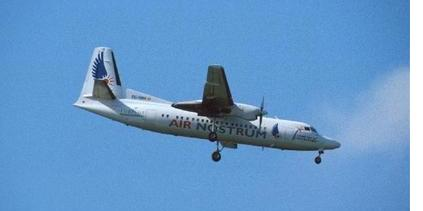

3. 	Image ID:  2167 		Distance:  0.06570607423782349


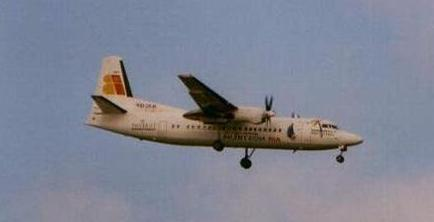

4. 	Image ID:  2301 		Distance:  0.07090252637863159


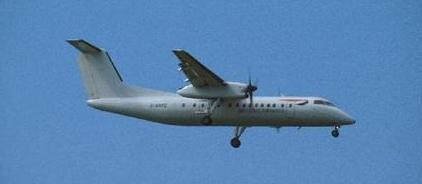

5. 	Image ID:  2203 		Distance:  0.07465589046478271


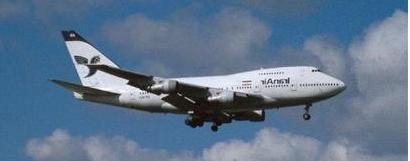

6. 	Image ID:  2254 		Distance:  0.07529681921005249


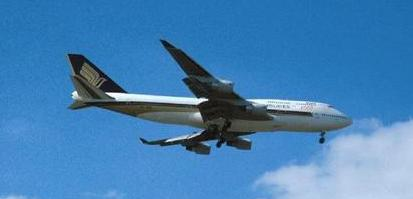

7. 	Image ID:  2253 		Distance:  0.07565945386886597


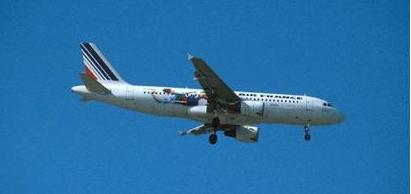

8. 	Image ID:  2670 		Distance:  0.07674413919448853


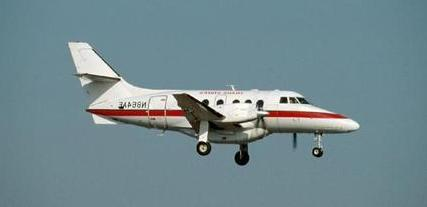

9. 	Image ID:  2527 		Distance:  0.07712769508361816


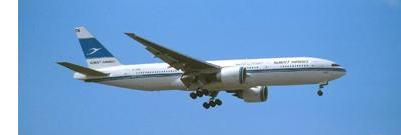

10. 	Image ID:  2252 		Distance:  0.07915341854095459


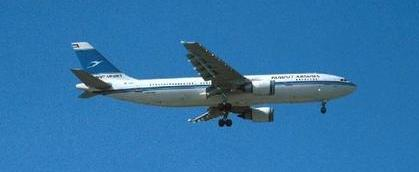

In [180]:
# ResNet-FC-1000.

# Find K most similar images by ResNet-FC-1000.

# Cosine similarity: We use Cosine since the output of the ResNet layer is 
# normalized, reducing the importance of magnitude. It is good at discerning 
# semantic or structural similarity rather than their absolute feature values. 
# It also works well with sparse feature spaces such as those found in CNNs.

print("Similar images by ResNet-FC-1000 using distance: Cosine")

top_k_by_fc1000 = top_k_ranker(K, fc1000_vector, fc1000_tensor_dict, cosine)


for i in range(len(top_k_by_fc1000)):

    id = top_k_by_fc1000[i][1]
    distance = top_k_by_fc1000[i][0]

    print(str(i + 1) + ".", "\tImage ID: ", id, "\t\tDistance: ", distance)
    display(dataset[id][0])